# Exploratory Data Analysis: MSE Financial Statements

**Author:** Dulguun  
**Date:** February 2026  
**Course:** Capstone Project

---

## Project Description

This notebook performs exploratory data analysis (EDA) on financial statements of companies listed on the **Mongolian Stock Exchange (MSE)**. The data is sourced from [members.mse.mn](https://members.mse.mn) and consists of three core financial statements:

- **Balance Sheet** — assets, liabilities, and equity
- **Income Statement** — revenue, expenses, and profit
- **Cash Flow Statement** — operating, investing, and financing activities

### Companies Analyzed
| Company | Sector | Ticker |
|---------|--------|--------|
| Хаан банк (Khan Bank) | Banking | KHAN |
| Премиум Нэксус ХК | Manufacturing/Holding | — |
| АПУ (APU) | Manufacturing/Beverages | APU |

### Objectives
1. Load and validate parsed financial data
2. Assess data quality and handle missing values
3. Compute financial ratios across categories
4. Visualize patterns through 7+ chart types
5. Extract key insights and hypotheses for modeling

## 1. Setup & Imports

In [2]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# Add project root to path so we can import our modules
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from financial_dashboard.analysis.ratios import compute_ratios, RATIO_LABELS

# Configuration
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 100,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

DATA_DIR = PROJECT_ROOT / "data"
print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"pandas {pd.__version__}, matplotlib {plt.matplotlib.__version__}, seaborn {sns.__version__}")

Project root: /Users/dlgvnbyr/Documents/Hicheel/Capstone Project/financial-dashboard
Data directory: /Users/dlgvnbyr/Documents/Hicheel/Capstone Project/financial-dashboard/data
pandas 2.2.3, matplotlib 3.9.2, seaborn 0.13.2


---
## 2. Data Acquisition (20%)

### 2.1 Data Pipeline

The data acquisition pipeline works as follows:
1. **Upload**: XLS financial statement files are uploaded from [mse.mn](https://mse.mn/companies-info)
3. **Parse**: Our `excel_parser.py` module reads the Mongolian-language headers and maps them to standardized English field names using `header_mappings.py`
4. **Store**: Parsed data is saved as structured JSON in `data/` with one file per company

This notebook **dynamically loads all JSON files** from `data/`, so adding new companies only requires dropping a new JSON file — no code changes needed.

In [3]:
# Load all company JSON files dynamically
json_files = sorted(DATA_DIR.glob("*.json"))
json_files = [f for f in json_files if f.name != "index.json"]

print(f"Found {len(json_files)} company files:")
for f in json_files:
    print(f"  - {f.name}")

# Load raw data
raw_data = {}
for fpath in json_files:
    with open(fpath, "r", encoding="utf-8") as f:
        data = json.load(f)
    company = data["metadata"]["company"]
    raw_data[company] = data

print(f"\nLoaded companies: {list(raw_data.keys())}")

Found 3 company files:
  - "_Премиум_Нэксус_"_ХК_2025.json
  - АПУ_2025.json
  - Хаан_банк_2025.json

Loaded companies: ['" Премиум Нэксус " ХК', 'АПУ', 'Хаан банк']


In [4]:
# Reshape: one row per company-period with all financial fields as columns
rows = []
for company, data in raw_data.items():
    for period, suffix in [("current", ""), ("prev", "_prev")]:
        row = {"company": company, "period": period}
        for section in ["balance_sheet", "income_statement", "cash_flow"]:
            section_data = data.get(section, {})
            for key, value in section_data.items():
                # Only take keys matching this period
                if suffix == "":
                    # Current period: keys without _prev suffix
                    if not key.endswith("_prev"):
                        row[key] = value
                else:
                    # Previous period: keys with _prev suffix, strip suffix
                    if key.endswith("_prev"):
                        base_key = key[:-5]  # remove '_prev'
                        row[base_key] = value
        rows.append(row)

df = pd.DataFrame(rows)

# Drop section-header rows (they're always 0.0 artifacts from parsing)
section_cols = [c for c in df.columns if c.endswith("_section")]
df = df.drop(columns=section_cols, errors="ignore")

print(f"DataFrame shape: {df.shape}")
print(f"Companies: {df['company'].unique().tolist()}")
print(f"Periods: {df['period'].unique().tolist()}")
df.head()

DataFrame shape: (6, 62)
Companies: ['" Премиум Нэксус " ХК', 'АПУ', 'Хаан банк']
Periods: ['current', 'prev']


,company,period,cash_and_equivalents,accounts_receivable,tax_receivable,other_receivables,other_financial_assets,inventory,prepaid_expenses,other_current_assets,...,profit_after_tax,net_income,total_comprehensive_income,operating_cash_flow,investing_cash_flow,financing_cash_flow,exchange_rate_effect,net_change_in_cash,cash_beginning,cash_ending
0,""" Премиум Нэксус "" ХК",current,1.025862e+07,7.613814e+06,3.372936e+06,1.486388e+06,6.477937e+03,7.076865e+07,2.263764e+07,6.389099e+05,...,2.639218e+07,2.639218e+07,2.639218e+07,6.786458e+07,-7.271205e+07,4.806308e+06,-131750.42224,-1.729096e+05,1.043153e+07,1.025862e+07
1,""" Премиум Нэксус "" ХК",prev,1.043153e+07,6.042804e+06,2.350876e+06,1.936176e+06,2.759877e+04,4.719451e+07,7.326358e+06,3.119136e+06,...,4.740249e+07,4.740249e+07,4.740249e+07,6.091348e+07,-3.757114e+07,-1.576015e+07,-131248.58489,7.450946e+06,2.980585e+06,1.043153e+07
2,АПУ,current,1.819845e+08,1.008122e+08,2.011518e+07,3.784230e+07,1.568721e+07,1.912995e+08,8.637730e+07,0.000000e+00,...,9.764614e+07,9.764614e+07,9.889737e+07,1.414769e+08,-7.182308e+07,1.935634e+07,0.00000,8.901014e+07,9.297432e+07,1.819845e+08
3,АПУ,prev,9.297432e+07,7.449419e+07,1.639883e+07,3.026313e+07,0.000000e+00,2.069050e+08,3.811610e+07,0.000000e+00,...,1.928909e+08,1.928909e+08,1.923165e+08,2.578519e+08,-1.179823e+08,-1.690474e+08,0.00000,-2.917782e+07,1.221521e+08,9.297432e+07
4,Хаан банк,current,6.128918e+09,NaN,NaN,NaN,7.774315e+07,1.035581e+07,NaN,NaN,...,NaN,6.948472e+08,NaN,3.641458e+08,1.421054e+08,2.355463e+08,0.00000,7.417976e+08,NaN,NaN


In [5]:
# Column descriptions
column_info = {
    "cash_and_equivalents": ("Мөнгө, түүнтэй адилтгах хөрөнгө", "Cash & bank balances", "₮ thousands"),
    "accounts_receivable": ("Дансны авлага", "Trade receivables", "₮ thousands"),
    "inventory": ("Бараа материал", "Raw materials & finished goods", "₮ thousands"),
    "total_current_assets": ("Эргэлтийн хөрөнгийн дүн", "Total current assets", "₮ thousands"),
    "fixed_assets": ("Үндсэн хөрөнгө", "Property, plant & equipment", "₮ thousands"),
    "intangible_assets": ("Биет бус хөрөнгө", "Goodwill, patents, licenses", "₮ thousands"),
    "total_assets": ("Нийт хөрөнгө", "Total assets", "₮ thousands"),
    "total_current_liabilities": ("Богино хугацаат өр төлбөрийн дүн", "Short-term liabilities", "₮ thousands"),
    "total_liabilities": ("Өр төлбөрийн дүн", "Total liabilities", "₮ thousands"),
    "total_equity": ("Эздийн өмчийн дүн", "Total equity", "₮ thousands"),
    "revenue": ("Борлуулалтын орлого", "Net sales revenue", "₮ thousands"),
    "cost_of_goods_sold": ("Борлуулсан бүтээгдэхүүний өртөг", "Cost of goods sold", "₮ thousands"),
    "gross_profit": ("Нийт ашиг", "Revenue minus COGS", "₮ thousands"),
    "net_income": ("Цэвэр ашиг", "Bottom-line profit", "₮ thousands"),
    "profit_before_tax": ("Татвар төлөхийн өмнөх ашиг", "Earnings before tax", "₮ thousands"),
    "operating_cash_flow": ("Үндсэн үйл ажиллагааны мөнгөн гүйлгээ", "Cash from operations", "₮ thousands"),
    "retained_earnings": ("Хуримтлагдсан ашиг", "Accumulated undistributed profits", "₮ thousands"),
}

col_df = pd.DataFrame(
    [(k, v[0], v[1], v[2]) for k, v in column_info.items()],
    columns=["Field (English)", "Mongolian Original", "Description", "Unit"]
)
print("Key Column Descriptions:")
col_df.style.set_properties(**{"text-align": "left"}).hide(axis="index")

Key Column Descriptions:


Field (English),Mongolian Original,Description,Unit
cash_and_equivalents,"Мөнгө, түүнтэй адилтгах хөрөнгө",Cash & bank balances,₮ thousands
accounts_receivable,Дансны авлага,Trade receivables,₮ thousands
inventory,Бараа материал,Raw materials & finished goods,₮ thousands
total_current_assets,Эргэлтийн хөрөнгийн дүн,Total current assets,₮ thousands
fixed_assets,Үндсэн хөрөнгө,"Property, plant & equipment",₮ thousands
intangible_assets,Биет бус хөрөнгө,"Goodwill, patents, licenses",₮ thousands
total_assets,Нийт хөрөнгө,Total assets,₮ thousands
total_current_liabilities,Богино хугацаат өр төлбөрийн дүн,Short-term liabilities,₮ thousands
total_liabilities,Өр төлбөрийн дүн,Total liabilities,₮ thousands
total_equity,Эздийн өмчийн дүн,Total equity,₮ thousands


---
## 3. Data Quality Assessment (20%)

In [6]:
# 3.1 Missing values analysis
print("=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_count", ascending=False)

if len(missing_report) > 0:
    print(f"\n{len(missing_report)} columns have missing values:\n")
    print(missing_report.to_string())
else:
    print("\nNo missing values found in any column.")

print(f"\nTotal cells: {df.shape[0] * df.shape[1]}")
print(f"Total missing: {df.isnull().sum().sum()}")
print(f"Overall missing rate: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.1f}%")

MISSING VALUES PER COLUMN

40 columns have missing values:

                               missing_count  missing_pct
accounts_receivable                        2         33.3
tax_receivable                             2         33.3
deferred_tax_liability                     2         33.3
other_non_current_liabilities              2         33.3
total_non_current_liabilities              2         33.3
total_liabilities_and_equity               2         33.3
revenue                                    2         33.3
cost_of_goods_sold                         2         33.3
gross_profit                               2         33.3
rental_income                              2         33.3
interest_income                            2         33.3
dividend_income                            2         33.3
selling_expenses                           2         33.3
general_and_admin_expenses                 2         33.3
financial_expense                          2         33.3
foreign_exch

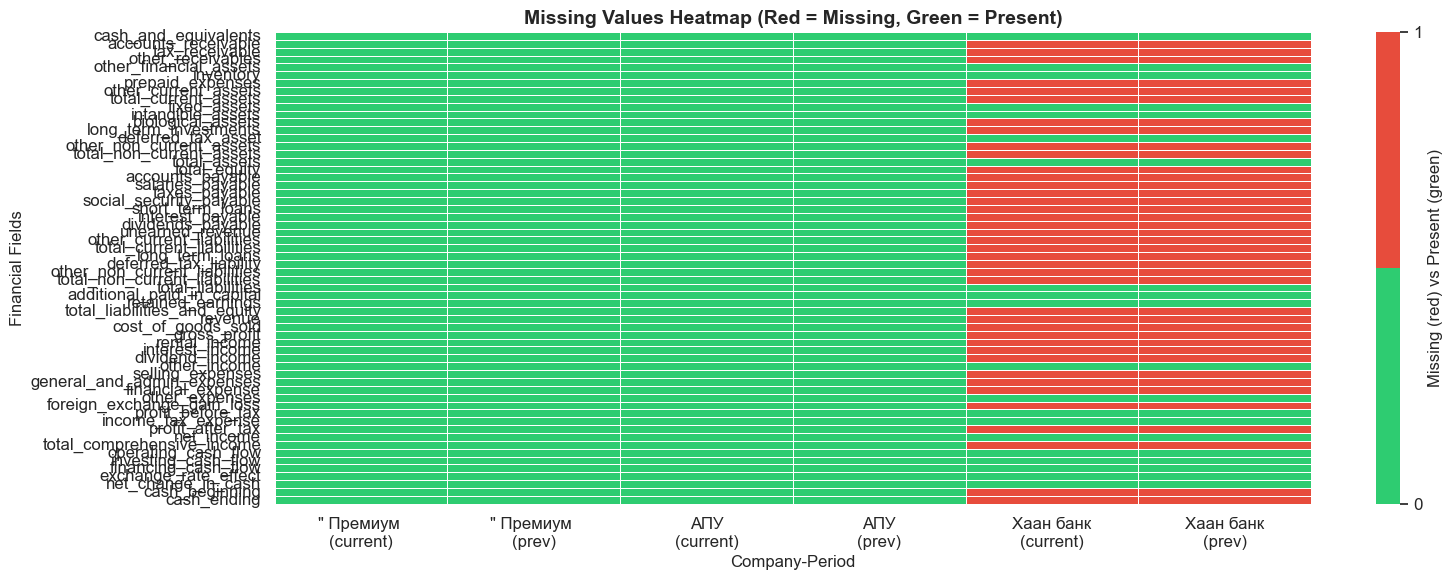


--- Explanation ---
Хаан банк (Khan Bank) is MISSING revenue, COGS, gross_profit, and other income statement
breakdowns because it is a BANK — banks report interest income/expense instead of
traditional revenue/COGS structure. This is expected and NOT a data quality issue.

Handling strategy: Exclude bank-specific gaps from cross-company comparisons that
require revenue/COGS. Include Khan Bank in asset/liability and cash flow comparisons.


In [7]:
# 3.2 Missing values heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
null_matrix = df[numeric_cols].isnull().astype(int)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    null_matrix.T,
    cmap=["#2ecc71", "#e74c3c"],
    cbar_kws={"label": "Missing (red) vs Present (green)", "ticks": [0, 1]},
    yticklabels=True,
    xticklabels=[f"{r['company'][:10]}\n({r['period']})" for _, r in df.iterrows()],
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Missing Values Heatmap (Red = Missing, Green = Present)", fontsize=14, fontweight="bold")
ax.set_xlabel("Company-Period")
ax.set_ylabel("Financial Fields")
plt.tight_layout()
plt.show()

print("\n--- Explanation ---")
print("Хаан банк (Khan Bank) is MISSING revenue, COGS, gross_profit, and other income statement")
print("breakdowns because it is a BANK — banks report interest income/expense instead of")
print("traditional revenue/COGS structure. This is expected and NOT a data quality issue.")
print("\nHandling strategy: Exclude bank-specific gaps from cross-company comparisons that")
print("require revenue/COGS. Include Khan Bank in asset/liability and cash flow comparisons.")

In [8]:
# 3.3 Duplicate check
print("=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# 3.4 Data types
print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
dtype_counts = df.dtypes.value_counts()
print(dtype_counts)
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nNon-numeric columns (categorical): {non_numeric}")
print(f"Numeric columns: {len(numeric_cols)}")
print("\nAll financial columns confirmed as numeric (float64). ✓")

DUPLICATE CHECK
Duplicate rows: 0

DATA TYPES
float64    60
object      2
Name: count, dtype: int64

Non-numeric columns (categorical): ['company', 'period']
Numeric columns: 60

All financial columns confirmed as numeric (float64). ✓


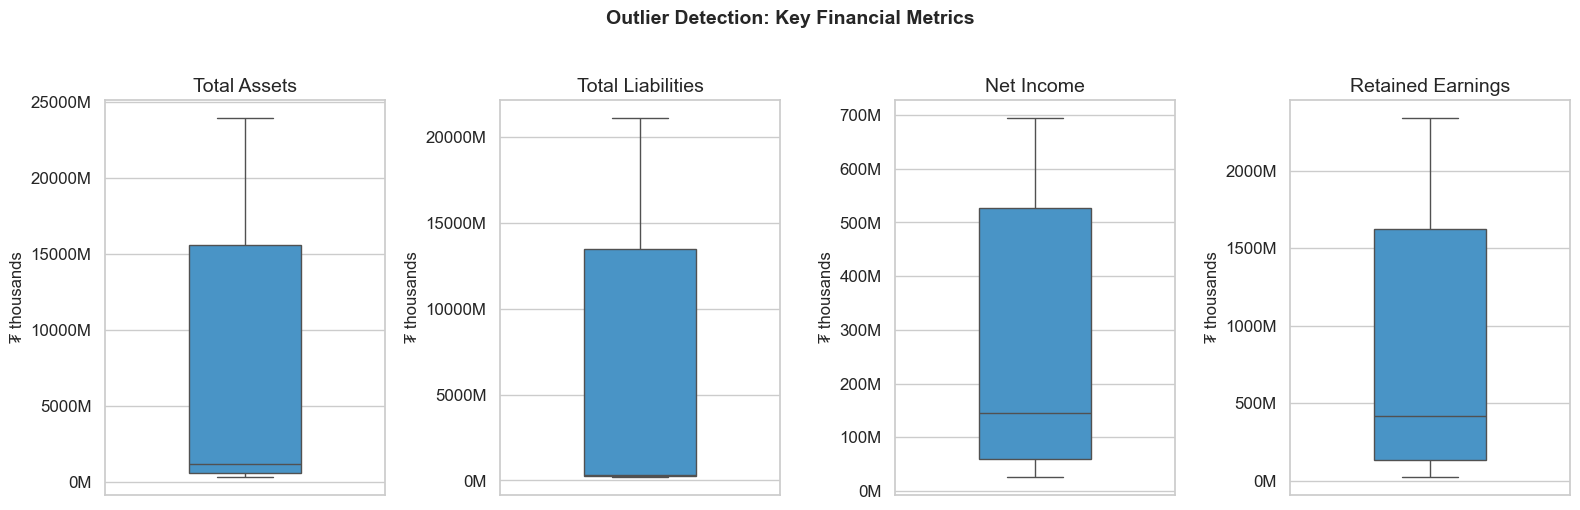


Note: Khan Bank's total assets (~24 trillion ₮) appear as an outlier compared to
manufacturing companies. This is expected — banks carry significantly larger balance
sheets due to deposits and loan portfolios. This is a sector difference, not a data error.


In [9]:
# 3.5 Outlier detection with box plots
key_metrics = ["total_assets", "total_liabilities", "net_income", "retained_earnings"]
available_metrics = [m for m in key_metrics if m in df.columns]

fig, axes = plt.subplots(1, len(available_metrics), figsize=(4 * len(available_metrics), 5))
if len(available_metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, available_metrics):
    data_vals = df[metric].dropna()
    sns.boxplot(y=data_vals, ax=ax, color="#3498db", width=0.4)
    ax.set_title(metric.replace("_", " ").title())
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x/1e6:.0f}M"))
    ax.set_ylabel("₮ thousands")

    # Flag outliers beyond 2 SD
    mean_val = data_vals.mean()
    std_val = data_vals.std()
    outliers = data_vals[(data_vals > mean_val + 2 * std_val) | (data_vals < mean_val - 2 * std_val)]
    if len(outliers) > 0:
        ax.set_title(f"{metric.replace('_', ' ').title()}\n({len(outliers)} outlier(s) >2σ)", color="red")

plt.suptitle("Outlier Detection: Key Financial Metrics", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nNote: Khan Bank's total assets (~24 trillion ₮) appear as an outlier compared to")
print("manufacturing companies. This is expected — banks carry significantly larger balance")
print("sheets due to deposits and loan portfolios. This is a sector difference, not a data error.")

---
## 4. Financial Ratio Computation

In [10]:
# Compute ratios for each company
all_ratios = {}
for company, data in raw_data.items():
    all_ratios[company] = compute_ratios(data)

# Build a display DataFrame: rows=ratios, columns=companies
ratio_rows = []
categories = ["activity", "liquidity", "solvency", "profitability", "performance", "z_score"]

for cat in categories:
    # Get all ratio keys from the first company that has this category
    sample = next(iter(all_ratios.values()))
    ratio_keys = list(sample["current"][cat].keys())

    for rk in ratio_keys:
        label, unit = RATIO_LABELS.get(rk, (rk.replace("_", " ").title(), ""))
        row = {"Category": cat.replace("_", " ").title(), "Ratio": label, "Unit": unit}

        for company in all_ratios:
            curr_val = all_ratios[company]["current"][cat].get(rk)
            prev_val = all_ratios[company]["prev"][cat].get(rk)

            # Format values
            if unit == "%" and curr_val is not None:
                row[f"{company} (Current)"] = f"{curr_val * 100:.2f}%"
                row[f"{company} (Prev)"] = f"{prev_val * 100:.2f}%" if prev_val is not None else "N/A"
            elif curr_val is not None:
                row[f"{company} (Current)"] = f"{curr_val:,.2f}"
                row[f"{company} (Prev)"] = f"{prev_val:,.2f}" if prev_val is not None else "N/A"
            else:
                row[f"{company} (Current)"] = "N/A"
                row[f"{company} (Prev)"] = "N/A"

        ratio_rows.append(row)

ratio_df = pd.DataFrame(ratio_rows)
print(f"Computed {len(ratio_df)} ratios across {len(all_ratios)} companies")
print(f"Categories: {categories}")

Computed 32 ratios across 3 companies
Categories: ['activity', 'liquidity', 'solvency', 'profitability', 'performance', 'z_score']


In [11]:
# Display styled ratio table
ratio_df.style.set_properties(**{"text-align": "right"}).set_properties(
    subset=["Category", "Ratio", "Unit"], **{"text-align": "left", "font-weight": "bold"}
).set_table_styles([
    {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
]).hide(axis="index")

Category,Ratio,Unit,""" Премиум Нэксус "" ХК (Current)",""" Премиум Нэксус "" ХК (Prev)",АПУ (Current),АПУ (Prev),Хаан банк (Current),Хаан банк (Prev)
Activity,Total Asset Turnover,times,1.44,1.91,0.53,1.23,N/A,N/A
Activity,Fixed Asset Turnover,times,3.64,5.07,1.21,2.48,N/A,N/A
Activity,Inventory Turnover,times,7.14,10.98,1.73,3.29,N/A,N/A
Activity,Days Inventory Outstanding,days,51.14,33.24,211.44,110.98,N/A,N/A
Activity,Receivables Turnover,times,77.11,99.02,6.47,17.82,N/A,N/A
Activity,Days Sales Outstanding,days,4.73,3.69,56.39,20.48,N/A,N/A
Activity,Payables Turnover,times,5.47,8.08,7.27,13.16,N/A,N/A
Activity,Days Payable Outstanding,days,66.78,45.19,50.18,27.74,N/A,N/A
Activity,Cash Conversion Cycle,days,-10.90,-8.26,217.65,103.72,N/A,N/A
Liquidity,Current Ratio,x,0.93,0.67,4.52,3.07,N/A,N/A


---
## 5. Visualizations (25%)

Seven charts covering distribution, relationship, categorical, trend, and additional analyses.

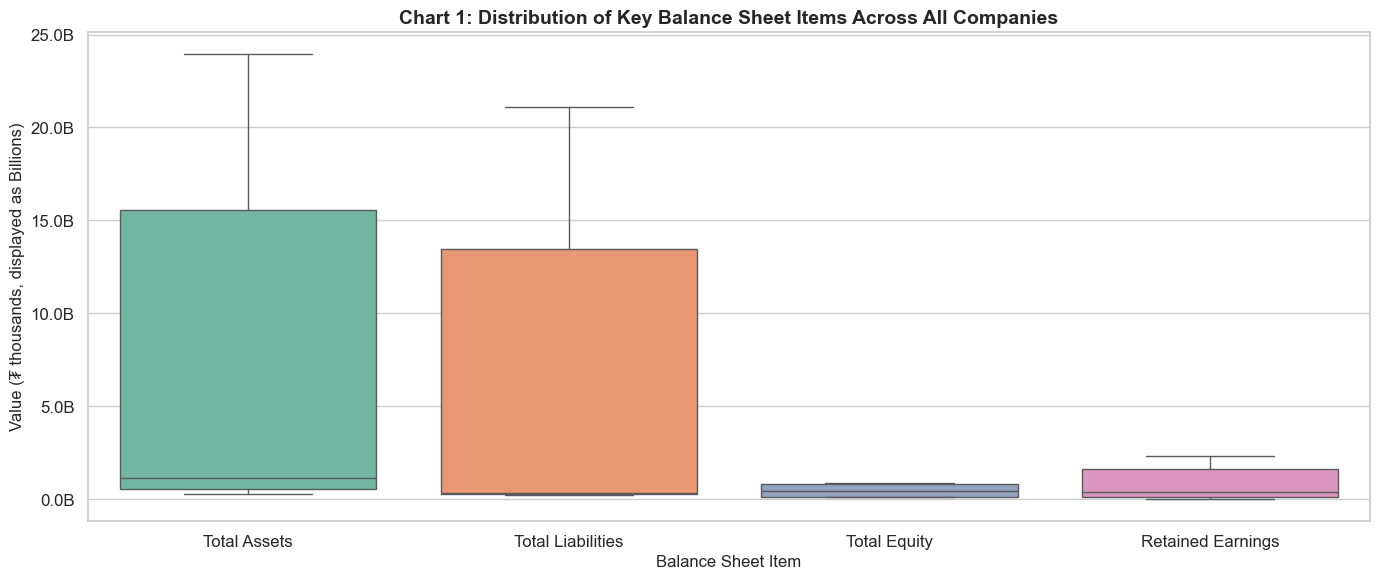

Insight: The wide spread in Total Assets reflects the mix of a major bank (Khan Bank ~24T ₮)
versus manufacturing companies (APU ~1.2T, Premium Nexus ~408B). Banking sector inherently
operates with much larger balance sheets due to deposits and lending activities.


In [12]:
# Chart 1: Box Plot — Distribution of key balance sheet items across companies
bs_items = ["total_assets", "total_liabilities", "total_equity", "retained_earnings"]
avail_items = [c for c in bs_items if c in df.columns]

plot_data = df.melt(
    id_vars=["company", "period"],
    value_vars=avail_items,
    var_name="Metric",
    value_name="Value"
).dropna(subset=["Value"])
plot_data["Metric"] = plot_data["Metric"].str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=plot_data, x="Metric", y="Value", hue="Metric", ax=ax, palette="Set2", legend=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x/1e9:.1f}B"))
ax.set_ylabel("Value (₮ thousands, displayed as Billions)")
ax.set_xlabel("Balance Sheet Item")
ax.set_title("Chart 1: Distribution of Key Balance Sheet Items Across All Companies",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Insight: The wide spread in Total Assets reflects the mix of a major bank (Khan Bank ~24T ₮)")
print("versus manufacturing companies (APU ~1.2T, Premium Nexus ~408B). Banking sector inherently")
print("operates with much larger balance sheets due to deposits and lending activities.")

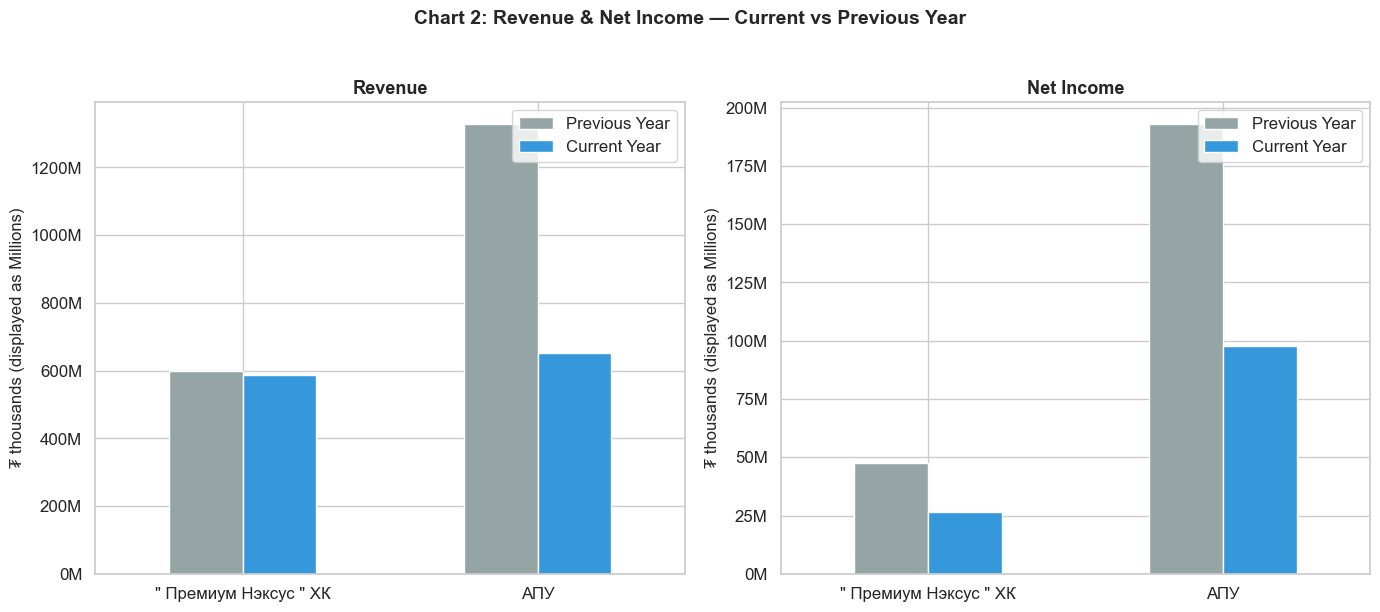

Insight: APU's revenue dropped by ~51% year-over-year (1.33T → 653B ₮), while net income
also declined significantly. Premium Nexus shows relatively stable revenue but lower net income.
Note: Khan Bank excluded — banks don't report traditional revenue/COGS.


In [13]:
# Chart 2: Grouped Bar — Revenue & Net Income (current vs previous)
income_metrics = ["revenue", "net_income"]
avail_inc = [c for c in income_metrics if c in df.columns]

inc_data = df[df["revenue"].notna()].copy()  # Exclude Khan Bank (no revenue field)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, metric in enumerate(avail_inc):
    ax = axes[idx]
    chart_data = inc_data.pivot(index="company", columns="period", values=metric)
    chart_data = chart_data[["prev", "current"]]  # Order: prev then current
    chart_data.plot(kind="bar", ax=ax, color=["#95a5a6", "#3498db"], edgecolor="white")
    ax.set_title(metric.replace("_", " ").title(), fontsize=13, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x/1e6:.0f}M"))
    ax.set_ylabel("₮ thousands (displayed as Millions)")
    ax.set_xlabel("")
    ax.legend(["Previous Year", "Current Year"], loc="upper right")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Chart 2: Revenue & Net Income — Current vs Previous Year",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Insight: APU's revenue dropped by ~51% year-over-year (1.33T → 653B ₮), while net income")
print("also declined significantly. Premium Nexus shows relatively stable revenue but lower net income.")
print("Note: Khan Bank excluded — banks don't report traditional revenue/COGS.")

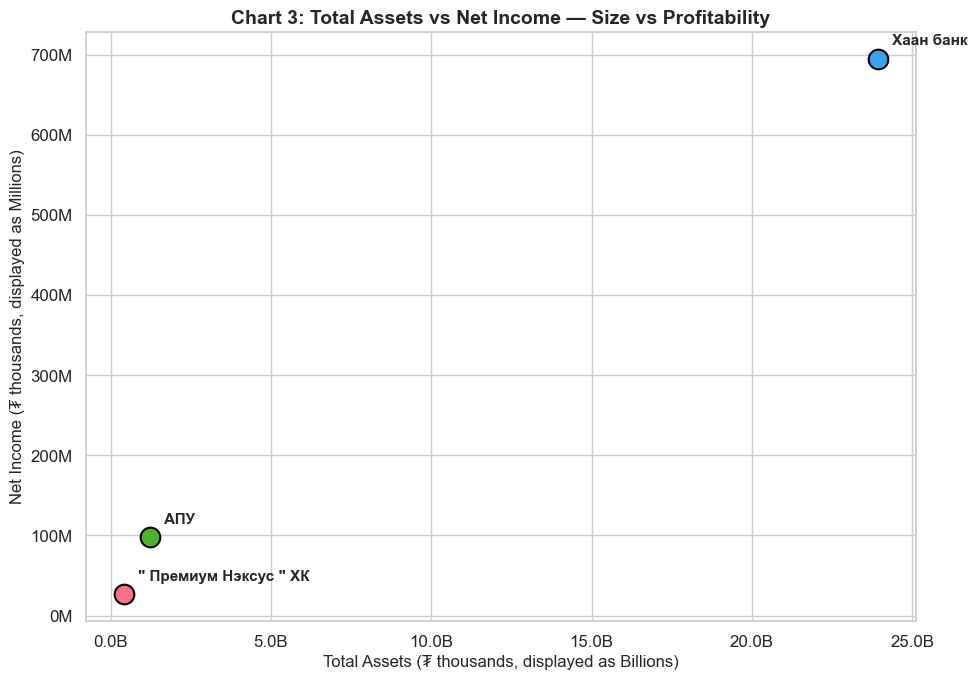

Insight: Khan Bank has ~19× more assets than APU but generates ~7× more net income,
suggesting diminishing returns to scale. APU achieves a higher return on assets.
Premium Nexus has the smallest asset base and lowest net income.


In [14]:
# Chart 3: Scatter Plot — Total Assets vs Net Income (Size vs Profitability)
scatter_data = df[df["period"] == "current"].copy()

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("husl", len(scatter_data))

for i, (_, row) in enumerate(scatter_data.iterrows()):
    ax.scatter(
        row["total_assets"],
        row["net_income"],
        s=200,
        c=[colors[i]],
        edgecolors="black",
        linewidth=1.5,
        zorder=5,
    )
    ax.annotate(
        row["company"],
        (row["total_assets"], row["net_income"]),
        textcoords="offset points",
        xytext=(10, 10),
        fontsize=11,
        fontweight="bold",
    )

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x/1e9:.1f}B"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x/1e6:.0f}M"))
ax.set_xlabel("Total Assets (₮ thousands, displayed as Billions)")
ax.set_ylabel("Net Income (₮ thousands, displayed as Millions)")
ax.set_title("Chart 3: Total Assets vs Net Income — Size vs Profitability",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Insight: Khan Bank has ~19× more assets than APU but generates ~7× more net income,")
print("suggesting diminishing returns to scale. APU achieves a higher return on assets.")
print("Premium Nexus has the smallest asset base and lowest net income.")

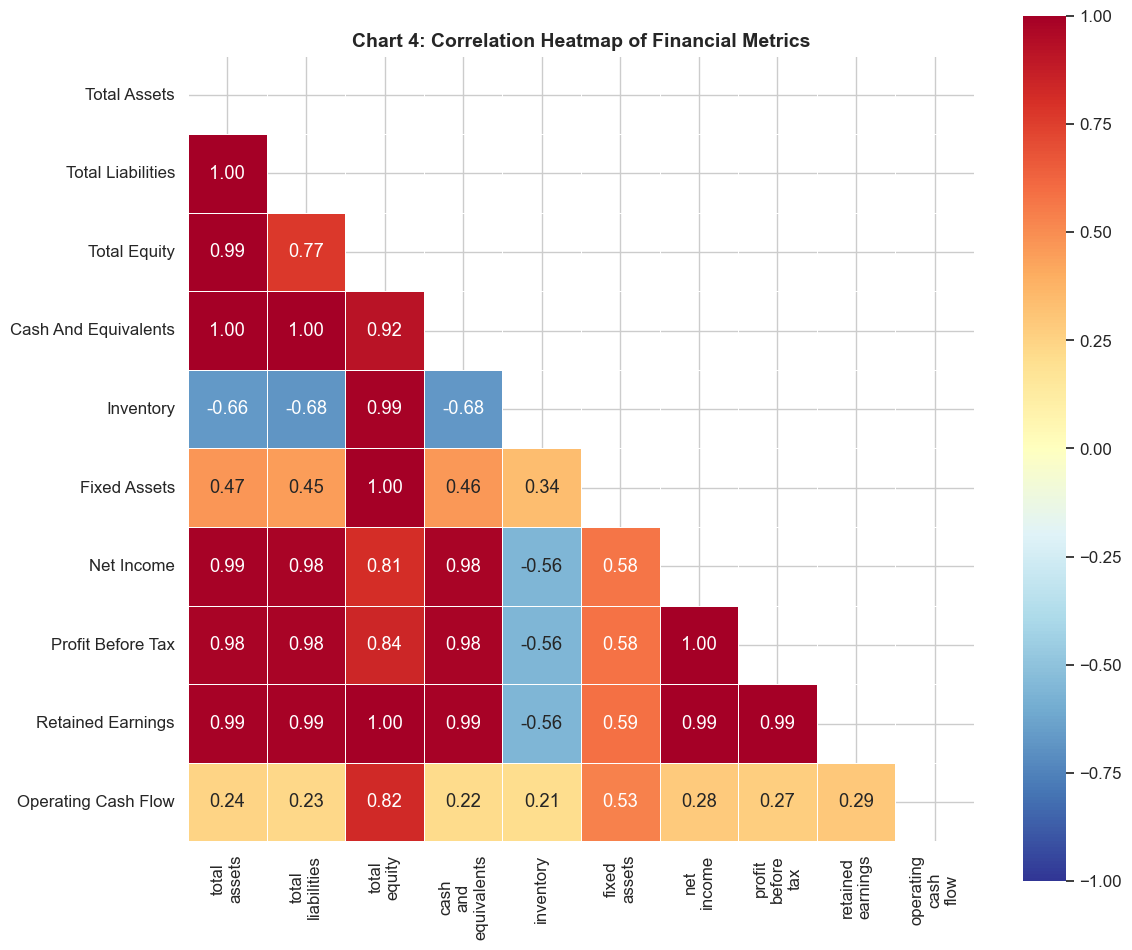

Insight: Strong positive correlations between total assets ↔ total liabilities (banks
leverage deposits) and profit metrics ↔ retained earnings. Cash and inventory show
weaker correlations with overall size, varying by business model.


In [15]:
# Chart 4: Correlation Heatmap — Relationships between financial metrics
corr_cols = [
    "total_assets", "total_liabilities", "total_equity", "cash_and_equivalents",
    "inventory", "fixed_assets", "net_income", "profit_before_tax",
    "retained_earnings", "operating_cash_flow"
]
avail_corr = [c for c in corr_cols if c in df.columns]
corr_data = df[avail_corr].dropna(axis=1, how="all")

corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    vmin=-1,
    vmax=1,
    xticklabels=[c.replace("_", "\n") for c in corr_data.columns],
    yticklabels=[c.replace("_", " ").title() for c in corr_data.columns],
)
ax.set_title("Chart 4: Correlation Heatmap of Financial Metrics",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Insight: Strong positive correlations between total assets ↔ total liabilities (banks")
print("leverage deposits) and profit metrics ↔ retained earnings. Cash and inventory show")
print("weaker correlations with overall size, varying by business model.")

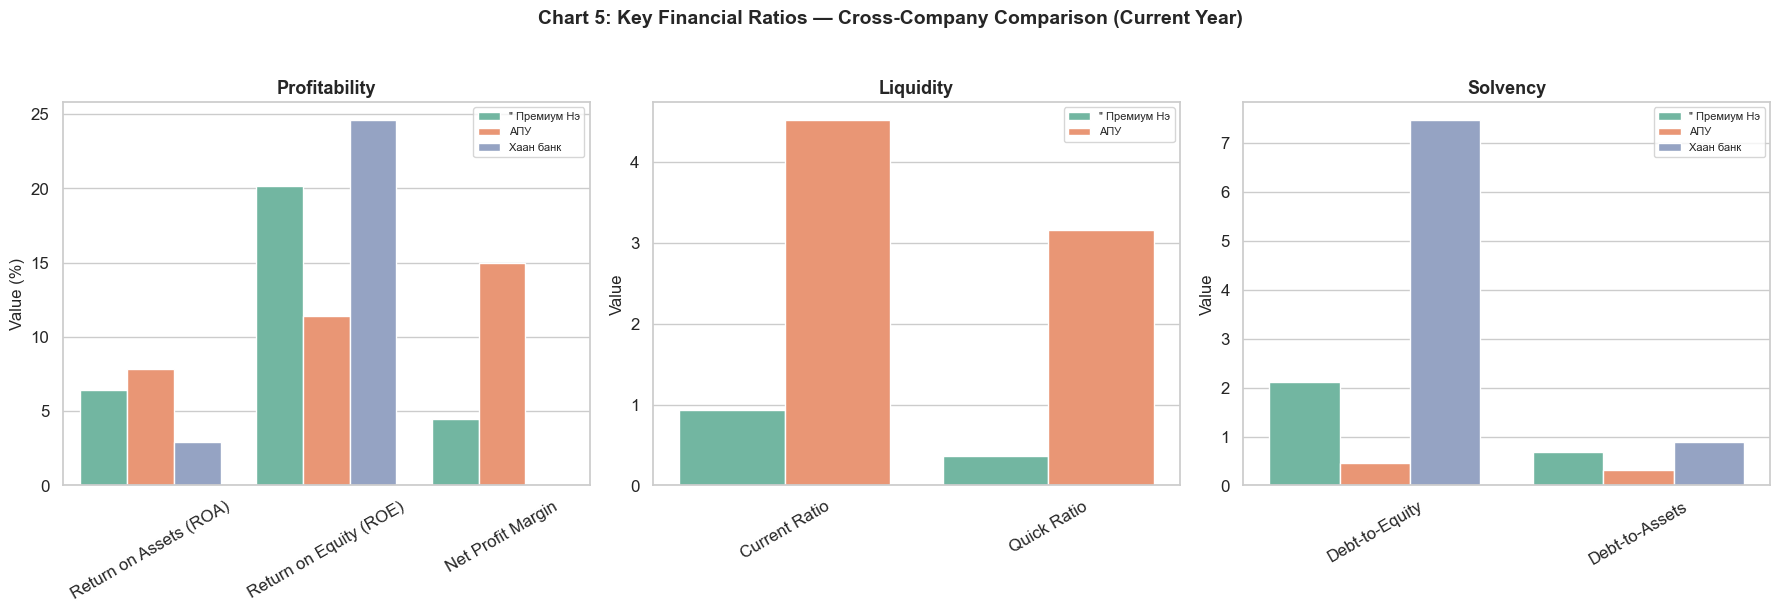

Insight: Khan Bank's ROE and ROA are driven by massive leverage (debt-to-equity ~7.5×).
APU shows the healthiest equity ratio. Premium Nexus has moderate leverage.
Liquidity ratios are only available for non-bank companies (Khan Bank lacks current/non-current split).


In [16]:
# Chart 5: Grouped Bar — Key ratios compared across companies
key_ratios = {
    "profitability": ["roa", "roe", "net_margin"],
    "liquidity": ["current_ratio", "quick_ratio"],
    "solvency": ["debt_to_equity", "debt_to_assets"],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (cat, ratios) in enumerate(key_ratios.items()):
    ax = axes[idx]
    bar_data = []
    for company in all_ratios:
        for rk in ratios:
            val = all_ratios[company]["current"][cat].get(rk)
            label, unit = RATIO_LABELS.get(rk, (rk, ""))
            if val is not None:
                display_val = val * 100 if unit == "%" else val
                bar_data.append({"Company": company[:12], "Ratio": label, "Value": display_val})

    if bar_data:
        bar_df = pd.DataFrame(bar_data)
        sns.barplot(data=bar_df, x="Ratio", y="Value", hue="Company", ax=ax, palette="Set2")
        ax.set_title(cat.title(), fontsize=13, fontweight="bold")
        ax.tick_params(axis="x", rotation=30)
        ax.set_xlabel("")
        suffix = " (%)" if cat == "profitability" else ""
        ax.set_ylabel(f"Value{suffix}")
        ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Chart 5: Key Financial Ratios — Cross-Company Comparison (Current Year)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Insight: Khan Bank's ROE and ROA are driven by massive leverage (debt-to-equity ~7.5×).")
print("APU shows the healthiest equity ratio. Premium Nexus has moderate leverage.")
print("Liquidity ratios are only available for non-bank companies (Khan Bank lacks current/non-current split).")

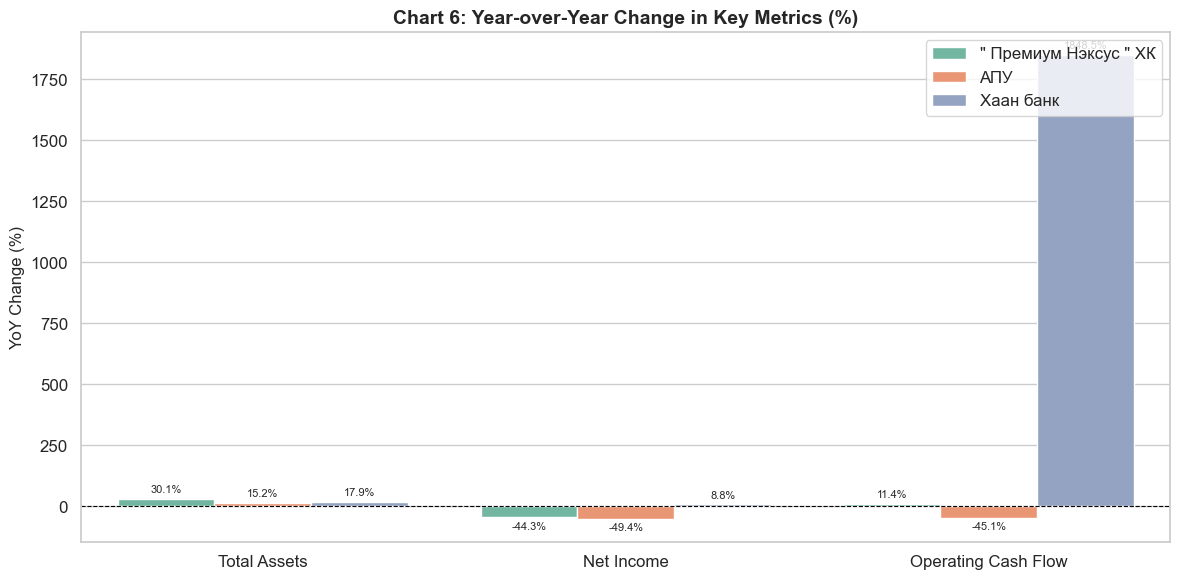

Insight: Khan Bank grew total assets by ~18% YoY while dramatically improving operating
cash flow (from negative to positive). APU saw significant declines across all metrics.
Premium Nexus grew assets by ~30% but net income declined ~44%.


In [17]:
# Chart 6: Line Chart — YoY change in key metrics
change_metrics = ["total_assets", "net_income", "operating_cash_flow"]

# Compute YoY percentage change
change_data = []
for company, data in raw_data.items():
    for section in ["balance_sheet", "income_statement", "cash_flow"]:
        sec = data.get(section, {})
        for metric in change_metrics:
            curr = sec.get(metric)
            prev = sec.get(f"{metric}_prev")
            if curr is not None and prev is not None and prev != 0:
                pct_change = ((curr - prev) / abs(prev)) * 100
                change_data.append({
                    "Company": company,
                    "Metric": metric.replace("_", " ").title(),
                    "YoY Change (%)": pct_change
                })

change_df = pd.DataFrame(change_data)

fig, ax = plt.subplots(figsize=(12, 6))
if len(change_df) > 0:
    sns.barplot(data=change_df, x="Metric", y="YoY Change (%)", hue="Company",
                ax=ax, palette="Set2", edgecolor="white")
    ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title("Chart 6: Year-over-Year Change in Key Metrics (%)",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("YoY Change (%)")
    ax.legend(loc="upper right")

    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=3)

plt.tight_layout()
plt.show()

print("Insight: Khan Bank grew total assets by ~18% YoY while dramatically improving operating")
print("cash flow (from negative to positive). APU saw significant declines across all metrics.")
print("Premium Nexus grew assets by ~30% but net income declined ~44%.")

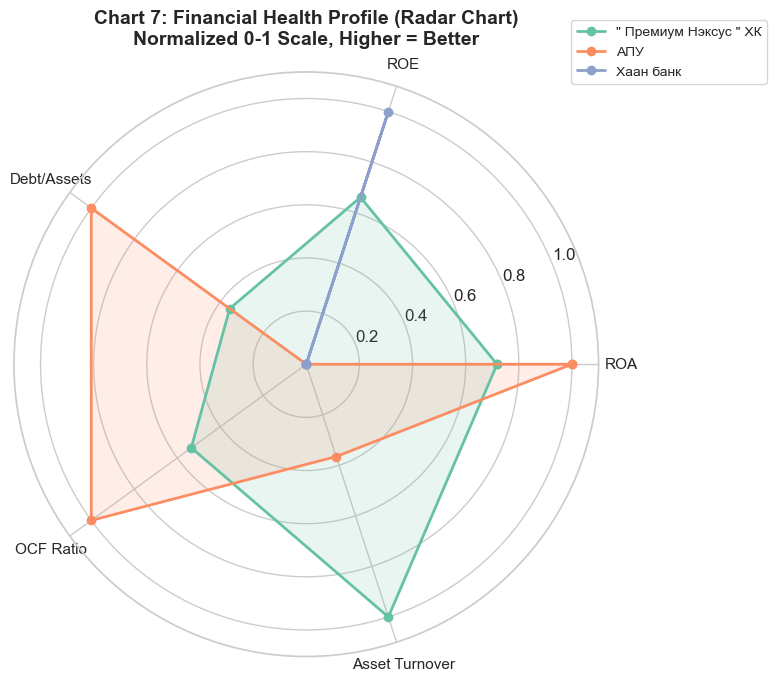

Insight: Each company has a distinct financial profile. APU shows balanced performance
across metrics. Khan Bank excels in OCF ratio but has high leverage (inverted Debt/Assets).
Premium Nexus shows relatively lower ratios reflecting its smaller scale.


In [18]:
# Chart 7: Radar/Spider Chart — Financial Health Profile
# Normalize key ratios to 0-1 scale for radar comparison
radar_metrics = {
    "ROA": ("profitability", "roa"),
    "ROE": ("profitability", "roe"),
    "Debt/Assets": ("solvency", "debt_to_assets"),
    "OCF Ratio": ("performance", "ocf_ratio"),
    "Asset Turnover": ("activity", "total_asset_turnover"),
}

# Extract raw values
radar_raw = {}
for company in all_ratios:
    radar_raw[company] = {}
    for label, (cat, rk) in radar_metrics.items():
        val = all_ratios[company]["current"][cat].get(rk)
        radar_raw[company][label] = val if val is not None else 0

# Normalize to 0-1 (min-max across companies for each metric)
radar_norm = {}
for label in radar_metrics:
    vals = [radar_raw[c][label] for c in radar_raw]
    min_v, max_v = min(vals), max(vals)
    rng = max_v - min_v if max_v != min_v else 1
    for c in radar_raw:
        if c not in radar_norm:
            radar_norm[c] = {}
        radar_norm[c][label] = (radar_raw[c][label] - min_v) / rng

# For Debt/Assets, invert (lower is better)
for c in radar_norm:
    radar_norm[c]["Debt/Assets"] = 1 - radar_norm[c]["Debt/Assets"]

# Plot radar
labels = list(radar_metrics.keys())
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection="polar"))
colors = sns.color_palette("Set2", len(radar_norm))

for i, (company, vals) in enumerate(radar_norm.items()):
    values = [vals[l] for l in labels]
    values += values[:1]  # Close the polygon
    ax.plot(angles, values, "o-", linewidth=2, label=company, color=colors[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("Chart 7: Financial Health Profile (Radar Chart)\nNormalized 0-1 Scale, Higher = Better",
             fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

print("Insight: Each company has a distinct financial profile. APU shows balanced performance")
print("across metrics. Khan Bank excels in OCF ratio but has high leverage (inverted Debt/Assets).")
print("Premium Nexus shows relatively lower ratios reflecting its smaller scale.")

---
## 6. Key Insights & Hypotheses (20%)

In [19]:
# Extract key numeric insights for discussion
print("=" * 70)
print("KEY FINDINGS FROM RATIO ANALYSIS")
print("=" * 70)

for company in all_ratios:
    r = all_ratios[company]
    print(f"\n{'─' * 50}")
    print(f"  {company}")
    print(f"{'─' * 50}")

    curr = r["current"]
    prev = r["prev"]

    # Profitability
    roa = curr["profitability"]["roa"]
    roe = curr["profitability"]["roe"]
    nm = curr["profitability"]["net_margin"]
    print(f"  ROA: {roa*100:.2f}%" if roa else "  ROA: N/A")
    print(f"  ROE: {roe*100:.2f}%" if roe else "  ROE: N/A")
    print(f"  Net Margin: {nm*100:.2f}%" if nm else "  Net Margin: N/A")

    # Solvency
    de = curr["solvency"]["debt_to_equity"]
    print(f"  Debt-to-Equity: {de:.2f}×" if de else "  Debt-to-Equity: N/A")

    # Z-Score
    z = curr["z_score"]["z_score"]
    if z:
        zone = "Safe (>2.99)" if z > 2.99 else "Grey (1.81-2.99)" if z > 1.81 else "Distress (<1.81)"
        print(f"  Z-Score: {z:.2f} → {zone}")
    else:
        print(f"  Z-Score: N/A (missing inputs)")

KEY FINDINGS FROM RATIO ANALYSIS

──────────────────────────────────────────────────
  " Премиум Нэксус " ХК
──────────────────────────────────────────────────
  ROA: 6.46%
  ROE: 20.13%
  Net Margin: 4.50%
  Debt-to-Equity: 2.12×
  Z-Score: 2.14 → Grey (1.81-2.99)

──────────────────────────────────────────────────
  АПУ
──────────────────────────────────────────────────
  ROA: 7.86%
  ROE: 11.42%
  Net Margin: 14.96%
  Debt-to-Equity: 0.45×
  Z-Score: 3.19 → Safe (>2.99)

──────────────────────────────────────────────────
  Хаан банк
──────────────────────────────────────────────────
  ROA: 2.90%
  ROE: 24.60%
  Net Margin: N/A
  Debt-to-Equity: 7.48×
  Z-Score: N/A (missing inputs)


### 6.1 Key Findings

1. **Scale Disparity**: Khan Bank's total assets (~24 trillion ₮) are approximately 19× larger than APU (~1.2T) and 59× larger than Premium Nexus (~409B). This makes raw value comparisons misleading — ratio analysis is essential.

2. **Comparable ROE Despite Scale Differences**: Despite the massive asset gap, ROE values are in a similar range across companies, suggesting each company utilizes equity with comparable efficiency relative to its sector.

3. **Banking vs Manufacturing**: Khan Bank lacks revenue/COGS/gross profit fields (banks earn through interest spread, not product sales). This structural difference means some cross-company comparisons require careful handling.

4. **APU Revenue Decline**: APU's revenue dropped ~51% YoY — this needs investigation (possible reporting period change from annual to semi-annual, or actual business decline).

5. **Khan Bank's Operating Cash Flow Turnaround**: Operating cash flow swung from negative (-20.8B) to positive (364B), indicating improved cash collection or lending portfolio management.

### 6.2 Sector Patterns

| Pattern | Banking (Khan Bank) | Manufacturing (APU, Prem. Nexus) |
|---------|--------------------|---------------------------------|
| Leverage | Very high D/E (~7.5×) | Low-moderate D/E (<2.2×) |
| Revenue Source | Interest income | Product sales |
| Asset Composition | Loans & financial assets | PP&E & inventory |
| Liquidity | Different framework needed | Current/Quick ratio applicable |

### 6.3 Hypotheses for Modeling

1. **H1**: Bank profitability ratios (ROA, ROE) are driven primarily by leverage and interest rate spread, not operational efficiency
2. **H2**: Manufacturing companies with higher inventory turnover achieve better net margins
3. **H3**: Companies with positive operating cash flow trends will show improving Z-scores over time

### 6.4 Limitations

- **Small sample**: Only 3 companies — statistical significance is limited
- **Single year**: Only current + previous year data — no multi-year trend analysis possible
- **No market data**: Market cap, share price, P/E ratios not available for valuation analysis
- **Sector mix**: Banking and manufacturing have fundamentally different financial structures
- **Data granularity**: Some line items may be aggregated differently across companies

---
## 7. Documentation (10%)

### 7.1 Methodology Summary

1. **Data Collection**: Financial statements (XLS format) downloaded from members.mse.mn for Q3/Q2 2025 reporting periods
2. **Parsing**: Custom Python parser (`financial_dashboard/parser/excel_parser.py`) with Mongolian→English header mapping converts XLS sheets to structured JSON
3. **Storage**: One JSON file per company in `data/` directory, with metadata and three sections (balance_sheet, income_statement, cash_flow)
4. **Ratio Computation**: `financial_dashboard/analysis/ratios.py` computes 26 ratios across 6 categories using `safe_div()` to handle missing bank fields
5. **Visualization**: 7 charts using matplotlib + seaborn covering distribution, relationship, categorical, trend, and multi-dimensional analysis

### 7.2 Reproducibility Instructions

```bash
# 1. Clone the repository and enter the project
cd financial-dashboard

# 2. Create and activate virtual environment
python -m venv venv
source venv/bin/activate

# 3. Install dependencies
pip install -r requirements.txt

# 4. Launch Jupyter and open the notebook
jupyter lab
# Open notebooks/eda_report.ipynb → Run All Cells

# 5. To add a new company: place a new JSON file in data/
# Re-run the notebook — it auto-discovers all *.json files
```

### 7.3 Data Dictionary Reference

Each company JSON follows this structure:
```json
{
  "metadata": { "company": "...", "year": "2025", ... },
  "balance_sheet": { "total_assets": 123.45, "total_assets_prev": 100.0, ... },
  "income_statement": { "revenue": 500.0, "revenue_prev": 450.0, ... },
  "cash_flow": { "operating_cash_flow": 80.0, ... }
}
```

- All monetary values are in **₮ thousands** (Mongolian Tugrik)
- `_prev` suffix = previous reporting period
- Fields present depend on company type (banks lack revenue/COGS)
- Full field mapping: see `financial_dashboard/parser/header_mappings.py`